## 1️⃣Phase 1: Data Cleaning
#### 1. load the data
#### 2. explore it
#### 3. clean it using clean_data()

## 1} Imports

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2} Load

In [26]:
# Read csv DataSet
df = pd.read_csv("/content/AmesHousing.csv")

# Show Fisrt 5 Row
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## 3} shape & info

In [27]:
# Print The shape
print("Shape befor:", df.shape)

print()

# Data INFO
df.info()

Shape befor: (2930, 82)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   ob

## 4} Missing values

In [28]:
# Number of missing values

df.isnull().sum().sort_values(ascending=False)

,0
Pool QC,2917
Misc Feature,2824
Alley,2732
Fence,2358
Mas Vnr Type,1775
...,...
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0


## 5} Duplicates

In [29]:
df.duplicated().sum()

np.int64(0)

## 6} Boxplot before cleaning

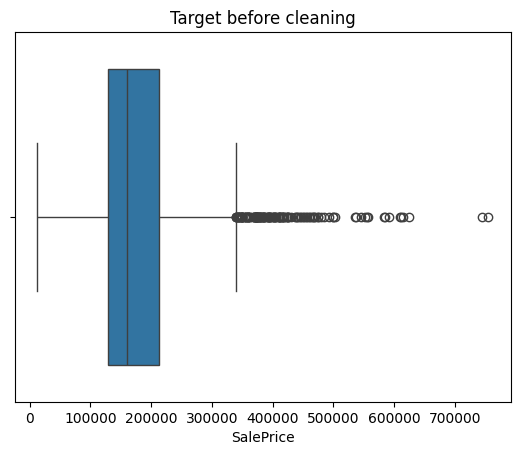

In [30]:
sns.boxplot(x=df["SalePrice"])
plt.title("Target before cleaning")
plt.show()

## 7} Column lists

In [31]:
# Drop column has more than 80% missing valus
drop_cols = ["Pool QC", "Misc Feature", "Alley", "Fence"]

# Feature doesn't exist in this house
cat_cols = [
    "Mas Vnr Type", "Fireplace Qu",
    "Bsmt Qual", "Bsmt Cond", "Bsmt Exposure", "BsmtFin Type 1", "BsmtFin Type 2",
    "Garage Type", "Garage Finish", "Garage Qual", "Garage Cond"
]

In [32]:
# Skewed so MEDIAN is safer then MEAN
median_cols = [
    "Lot Frontage", "Mas Vnr Area",
    "BsmtFin SF 1", "BsmtFin SF 2",
    "Bsmt Unf SF", "Total Bsmt SF"
]

# Symmetric so MEAN
mean_cols = ["Garage Yr Blt", "Garage Cars", "Garage Area"]

# Discrete counts so MODE
mode_cols = ["Bsmt Full Bath", "Bsmt Half Bath", "Electrical"]

## 8} fix_dtypes

In [33]:
def fix_dtypes(df):

    out = df.copy()

    # Converts to numeric
    out["Lot Frontage"] = pd.to_numeric(out["Lot Frontage"], errors="coerce")
    out["Mas Vnr Area"] = pd.to_numeric(out["Mas Vnr Area"], errors="coerce")
    return out

## 9} fill_missing

In [34]:
def fill_missing(df):
    out = df.copy()

    # Drop columns with >80% missing
    out = out.drop(columns=drop_cols)

    # Fill categorical missing with 'Unknown'
    for col in cat_cols:
            if col in out.columns:
                out[col] = out[col].fillna("Unknown")

    # Fill numeric skewed with MEDIAN
    for col in median_cols:
            if col in out.columns:
                out[col] = out[col].fillna(out[col].median())

    # Fill symmetric numeric with MEAN
    for col in mean_cols:
        if col in out.columns:
            out[col] = out[col].fillna(out[col].mean())

    # Fill discrete counts with MODE
    for col in mode_cols:
        if col in out.columns:
            out[col] = out[col].fillna(out[col].mode()[0])

    return out

#### Handling Missing Values


> - Drop columns with more than 80% missing values because they won't help us.
>
> - For categorical columns, fill missing with "Unknown" because people didn't answer.
> - For skewed numeric columns, median is a better choice.
> - For symmetric numeric columns, use mean because it won't be affected.
> - For count/discrete columns, use mode.

## 10} remove_duplicates

In [35]:
def remove_duplicates(df):

    return df.drop_duplicates()
    # Any duplicates will drop

## 11} cap_outliers

In [36]:
def cap_outliers(df):

    out = df.copy()

    Q1  = out["SalePrice"].quantile(0.25)
    Q3  = out["SalePrice"].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print("Outliers:", ((out["SalePrice"] < lower) | (out["SalePrice"] > upper)).sum())

    upper_99 = out["SalePrice"].quantile(0.99)
    out["SalePrice"] = out["SalePrice"].clip(upper=upper_99)

    # Reducing outliers

    return out

## 12} validate

In [37]:
def validate(df):

    # No nulls in key columns
    key_cols = ["SalePrice", "Lot Frontage", "Mas Vnr Area"]

    for col in key_cols:
        assert df[col].isna().sum() == 0, f"Column {col} has missing values"

    # All target values > 0
    assert df["SalePrice"].min() > 0, "SalePrice has non positive values"

    # Dataframe is not empty
    assert len(df) > 0, "DataFrame is empty"

    print("Data cleaning done successfully❤️")

## 13} clean_data

In [38]:
def clean_data(df):

    out = fix_dtypes(df)
    out = fill_missing(out)
    out = remove_duplicates(out)
    out = cap_outliers(out)
    validate(out)

    # Apply all pipline in one function
    return out

## 14} Apply

In [39]:
df = clean_data(df)

# See the new shape after cleaning
print("\nshape after:", df.shape)

Outliers: 137
Data cleaning done successfully❤️

shape after: (2930, 78)


## 15} Boxplot after cleaning

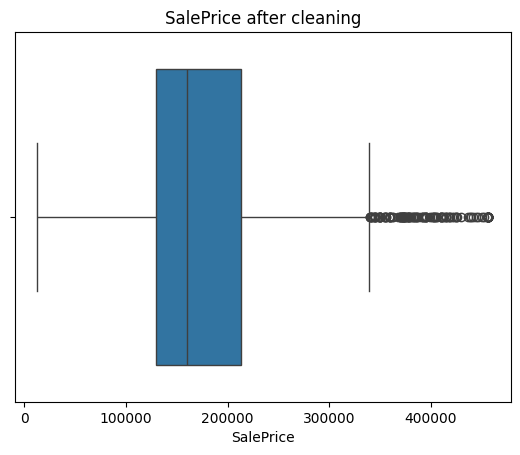

In [40]:
sns.boxplot(x=df["SalePrice"])
plt.title("SalePrice after cleaning")
plt.show()

# To more checks

In [41]:
# Make sure about missings

df.isnull().sum().sort_values(ascending=False)
# See the different betwen befor cleaning and after

,0
Order,0
PID,0
MS SubClass,0
MS Zoning,0
Lot Frontage,0
...,...
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0


In [42]:
# Save to CSV
df.to_csv("cleaned_data.csv", index=False)

# Save to XLSX
df.to_excel("cleaned_data.xlsx", index=False)

## done🌟

> #### dropped columns with over 80% missing
> #### no missing values
> #### no duplicates
> #### outliers capped
